In [1]:
# Celula 1 - Imports
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.cancer.dataset import load_cancer_dataframe, get_cancer_info

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports carregados')


Imports carregados


In [2]:
# Celula 2 - Informacoes do dataset
info = get_cancer_info()
for k, v in info.items():
    if k != 'feature_descriptions':
        print(f'{k}: {v}')


name: Breast Cancer Wisconsin (Diagnostic)
source: UCI Machine Learning Repository
url: https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data
samples: 569
features: 30
classes: ['B (benigno)', 'M (maligno)']
encoding: {'M': 1, 'B': 0}
task: classification


In [3]:
# Celula 3 - Carregar dados (target transformado: M=1, B=0)
df = load_cancer_dataframe()
print(f'Shape: {df.shape}')
print('\nPrimeiras 5 linhas:')
df.head()


Shape: (569, 32)

Primeiras 5 linhas:


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [4]:
# Celula 4 - Info e valores ausentes
print('Info do DataFrame:')
df.info()
print('\nValores ausentes por coluna:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Nenhum valor ausente!')
print('\nEstatisticas descritivas:')
df.drop(columns=['diagnosis']).describe().T.head(10)


Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area er

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


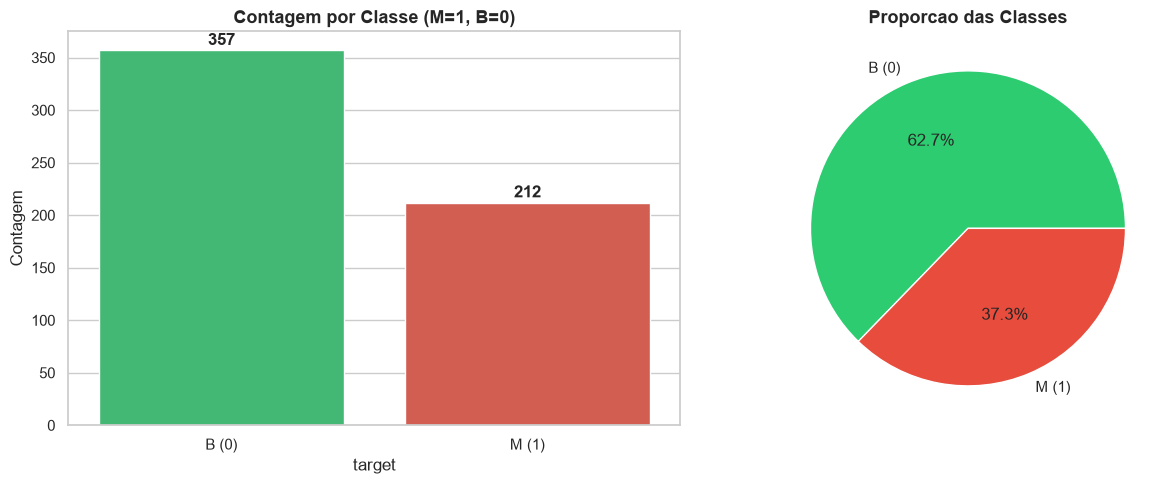

Distribuicao:
target
0    357
1    212
Name: count, dtype: int64

Proporcao M: 37.3% | B: 62.7%


In [5]:
# Celula 5 - Distribuicao da variavel target (M=1, B=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts().sort_index()
sns.countplot(x='target', hue='target', data=df, palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[0])
axes[0].set_title('Contagem por Classe (M=1, B=0)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('target')
axes[0].set_ylabel('Contagem')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['B (0)', 'M (1)'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df['target'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    labels=['B (0)', 'M (1)'], ax=axes[1]
)
axes[1].set_title('Proporcao das Classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('Distribuicao:')
print(df['target'].value_counts().sort_index())
print(f'\nProporcao M: {df["target"].mean()*100:.1f}% | B: {(1-df["target"].mean())*100:.1f}%')


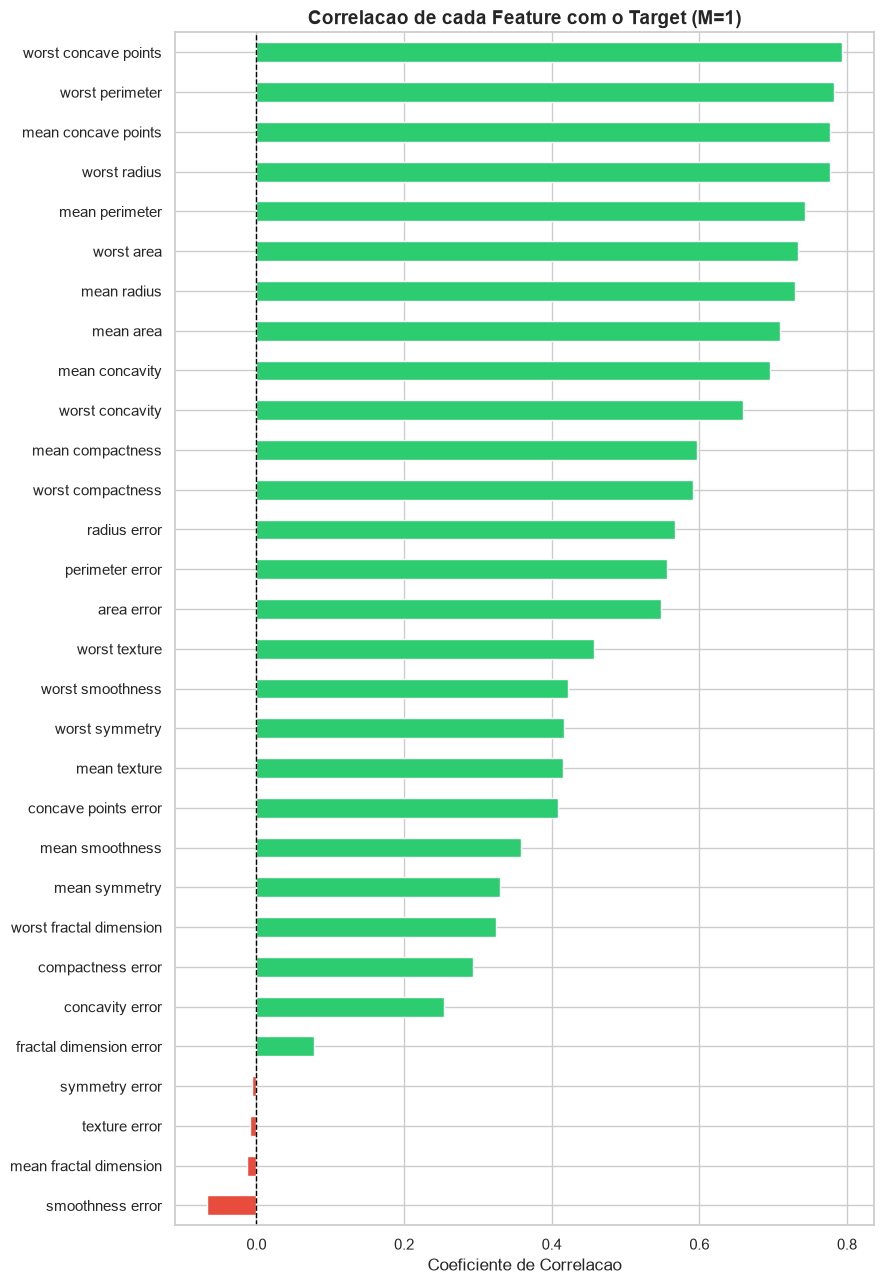

Top 10 features mais correlacionadas com M (1):
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
mean concavity          0.696
worst concavity         0.660
dtype: float64


In [6]:
# Celula 6 - Correlacao das features com o target
features = [c for c in df.columns if c not in ('diagnosis', 'target')]
corr_with_target = df[features].corrwith(df['target']).sort_values()

plt.figure(figsize=(9, 13))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Correlacao de cada Feature com o Target (M=1)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlacao')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print('Top 10 features mais correlacionadas com M (1):')
print(corr_with_target.sort_values(ascending=False).head(10).round(3))


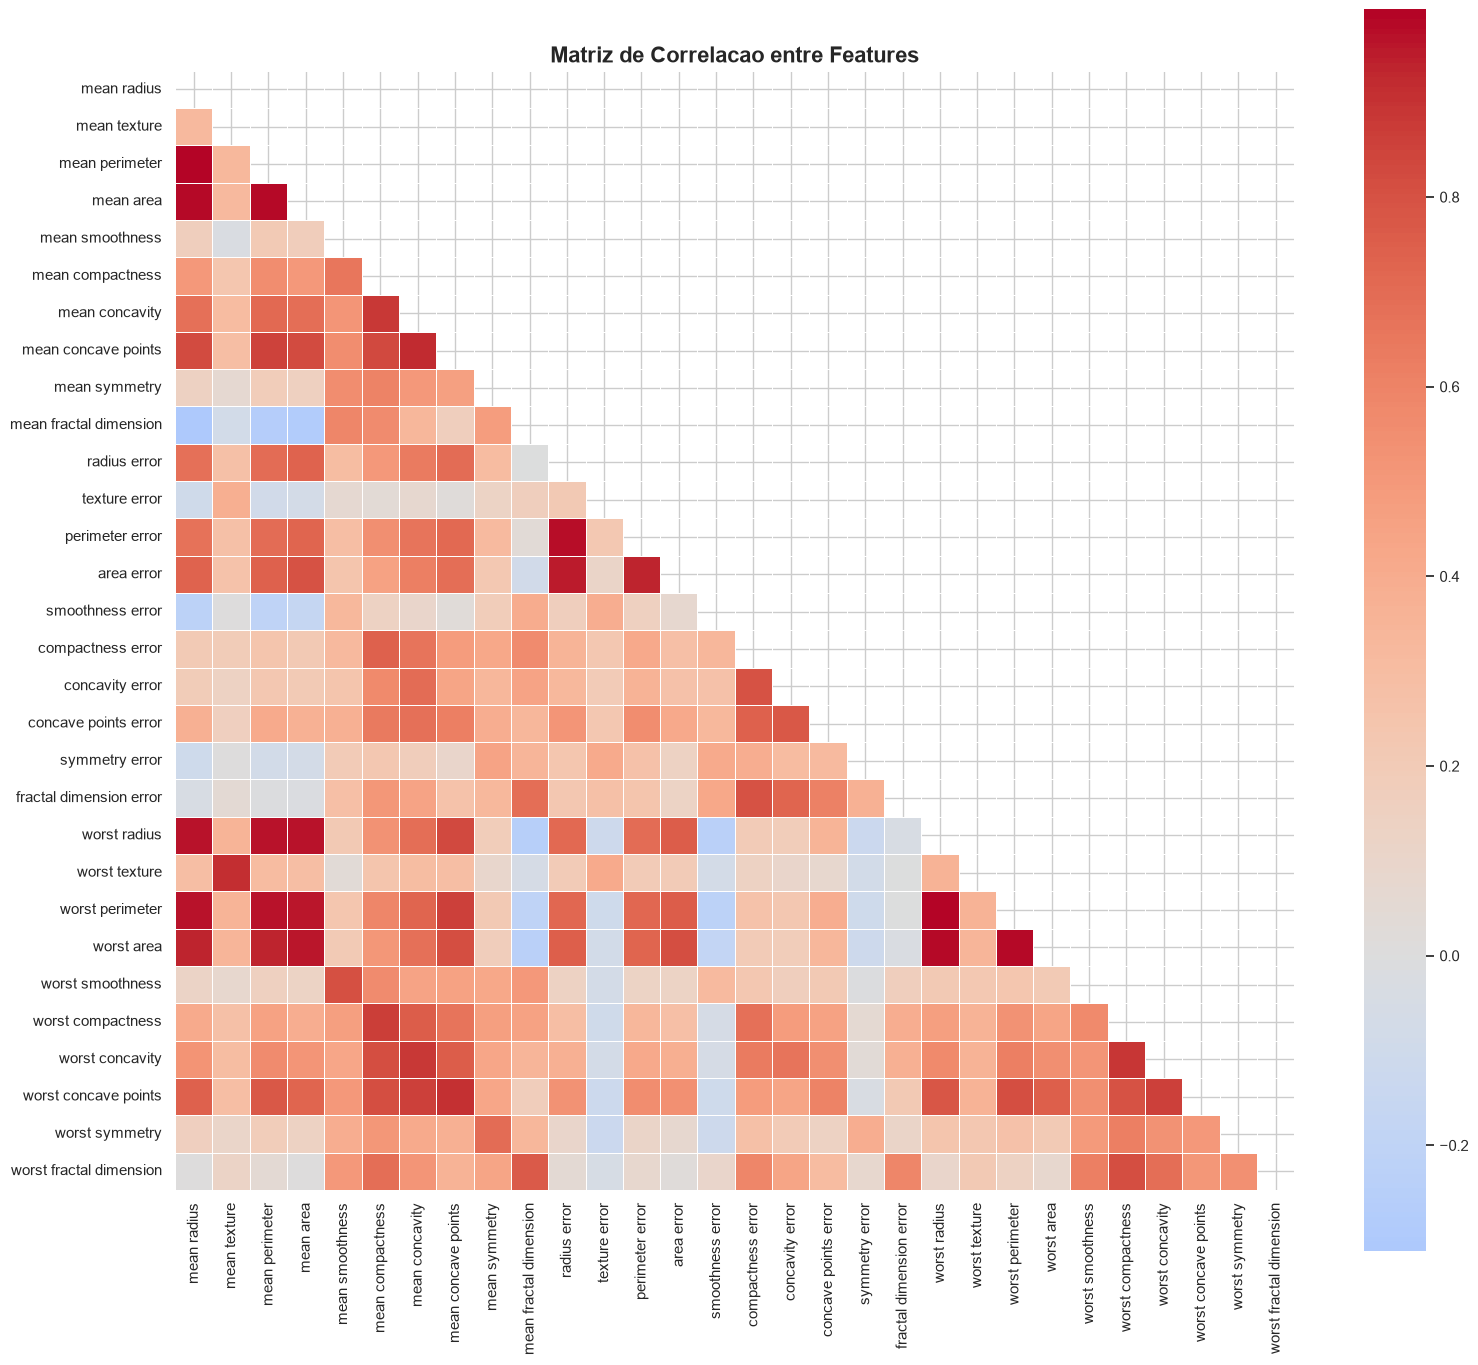

Features altamente correlacionadas (|r| > 0.9):
  - mean perimeter <-> mean radius: 0.998
  - mean area <-> mean radius: 0.987
  - mean area <-> mean perimeter: 0.987
  - mean concave points <-> mean concavity: 0.921
  - perimeter error <-> radius error: 0.973
  - area error <-> radius error: 0.952
  - area error <-> perimeter error: 0.938
  - worst radius <-> mean radius: 0.97
  - worst radius <-> mean perimeter: 0.969
  - worst radius <-> mean area: 0.963


In [7]:
# Celula 7 - Matriz de correlacao completa
plt.figure(figsize=(16, 14))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, square=True, linewidths=0.5)
plt.title('Matriz de Correlacao entre Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Features altamente correlacionadas (|r| > 0.9):')
high = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high.append((corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 3)))
for c1, c2, r in high[:10]:
    print(f'  - {c1} <-> {c2}: {r}')


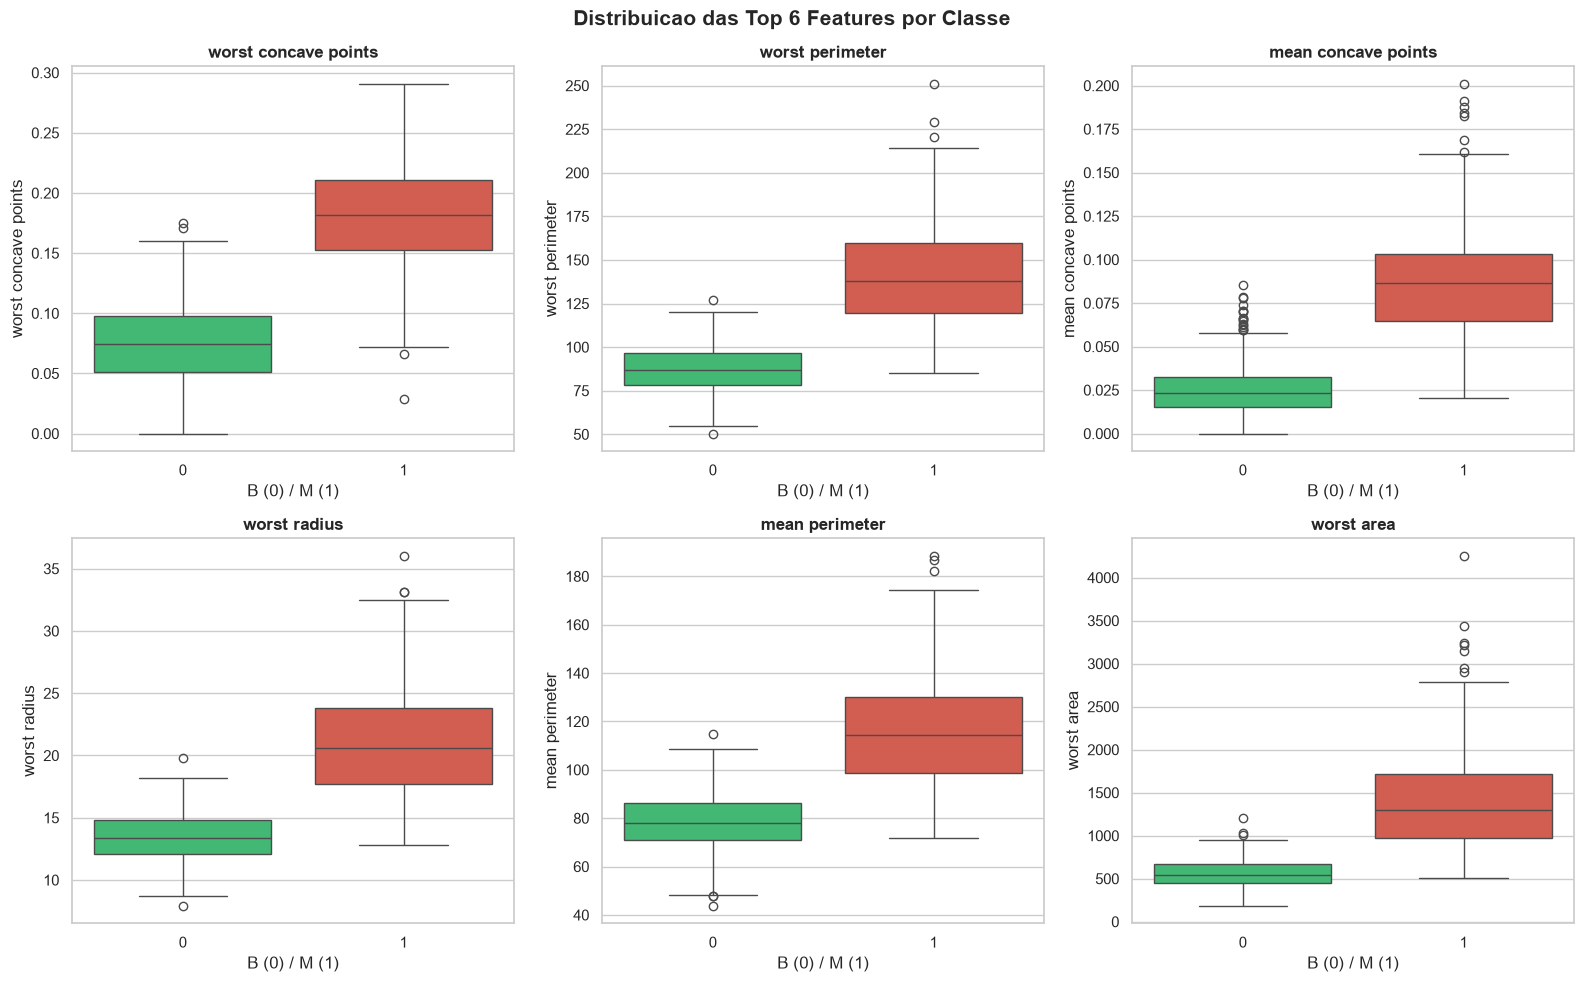

In [8]:
# Celula 8 - Boxplots das top 6 features por classe
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, feature in enumerate(top_features):
    sns.boxplot(x='target', y=df[feature], hue='target', data=df,
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[idx])
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('B (0) / M (1)')
plt.suptitle('Distribuicao das Top 6 Features por Classe', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [9]:
# Celula 9 - Estatisticas por classe
print('Estatisticas descritivas por classe (media das features):')
stats = df.groupby('target')[features].mean().T
stats.columns = ['B (0)', 'M (1)']
stats['diferenca'] = (stats['M (1)'] - stats['B (0)']).round(3)
stats.round(3).head(15)


Estatisticas descritivas por classe (media das features):


,B (0),M (1),diferenca
mean radius,12.147,17.463,5.316
mean texture,17.915,21.605,3.690
mean perimeter,78.075,115.365,37.290
mean area,462.790,978.376,515.586
mean smoothness,0.092,0.103,0.010
mean compactness,0.080,0.145,0.065
mean concavity,0.046,0.161,0.115
mean concave points,0.026,0.088,0.062
mean symmetry,0.174,0.193,0.019
mean fractal dimension,0.063,0.063,-0.000


In [10]:
# Celula 10 - Insights e conclusoes
print('''
=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 569 amostras, 30 features + diagnosis (M/B).
   - Transformacao aplicada: M -> 1 (maligno), B -> 0 (benigno)
   - 357 benignos (62.7%) | 212 malignos (37.3%)
2. SEM VALORES AUSENTES: dataset limpo, sem imputacao.
3. MULTICOLINEARIDADE ALTA: features de radius/perimeter/area
   correlacionadas > 0.9 (ex: mean radius <-> mean perimeter).
4. FEATURES MAIS RELEVANTES: worst perimeter, worst concave points,
   worst radius, mean concavity - todas correlacionadas com M (1).
5. SEPARABILIDADE: boas separacoes nas boxplots -> modelos devem
   alcancar alta acuracia.
6. PRE-PROCESSAMENTO: usar StandardScaler + stratified split.
=========================================================
''')



=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 569 amostras, 30 features + diagnosis (M/B).
   - Transformacao aplicada: M -> 1 (maligno), B -> 0 (benigno)
   - 357 benignos (62.7%) | 212 malignos (37.3%)
2. SEM VALORES AUSENTES: dataset limpo, sem imputacao.
3. MULTICOLINEARIDADE ALTA: features de radius/perimeter/area
   correlacionadas > 0.9 (ex: mean radius <-> mean perimeter).
4. FEATURES MAIS RELEVANTES: worst perimeter, worst concave points,
   worst radius, mean concavity - todas correlacionadas com M (1).
5. SEPARABILIDADE: boas separacoes nas boxplots -> modelos devem
   alcancar alta acuracia.
6. PRE-PROCESSAMENTO: usar StandardScaler + stratified split.

